#***DRAGO***#
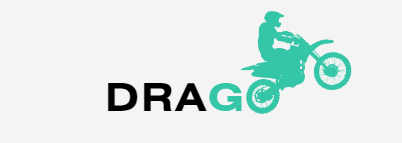
---


#**Project Overview**#

This project addresses traffic congestion in Riyadh, exacerbated by erratic delivery motorcycles causing frequent accidents. By employing a multi-model approach utilizing YOLO for real-time object detection, GRU for analyzing traffic patterns, and VGG16 for feature extraction, the project aims to enhance road safety and reduce congestion. Additionally, it analyzes traffic, environmental, and delivery data to develop data-driven solutions like dynamic routing and optimized delivery schedules. Ultimately, the project seeks to improve traffic management, enhance road safety, and reduce environmental pollution through optimized traffic flow.


# Setup for Video Object Detection and Analysis Environment#

In [ ]:
!pip install crewai langchain langchain-community langchain_groq

INFO: pip is looking at multiple versions of langchain-community to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain-groq to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of embedchain to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
INFO: pip is looking at multiple versions of mem0ai to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions o

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/Drago100

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid	yolov8n


In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.8/882.8 kB 54.1 MB/s eta 0:00:00


#***YOLOv8 Training and VGG16 Model Preparation***#


---



This code snippet performs several key tasks in a deep learning pipeline. First, it creates a YAML configuration file for training a YOLOv8 object detection model, specifying paths for training, validation, and test datasets, along with class names. The script then trains the YOLOv8 model using the specified configuration for 30 epochs and saves the trained model. Additionally, it initializes a VGG16 model pre-trained on ImageNet, which can be used for further image classification tasks.

In [ ]:
import cv2
import numpy as np
import yaml
from ultralytics import YOLO
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.preprocessing.image import img_to_array


yolo_yaml_content = """
# data.yaml
train: /content/drive/MyDrive/Drago100/train
val: /content/drive/MyDrive/Drago100/valid
test: /content/drive/MyDrive/Drago100/test

nc: 8  # Number of classes
names: ['Bike', 'Bus', 'Car', 'Motorcycle', 'Person', 'Truck', 'Accident', 'Undefined']
"""

yaml_file_path = '/content/drive/MyDrive/Drago100/data.yaml'
with open(yaml_file_path, 'w') as yaml_file:
    yaml_file.write(yolo_yaml_content)

print(f"YOLO configuration file created at {yaml_file_path}.")



yolo_model = YOLO('yolov8n.pt')


yolo_model.train(data=yaml_file_path, epochs=30, batch=16)

yolo_model.save('trained_yolov8.pt')


vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO configuration file created at /content/drive/MyDrive/Drago100/data.yaml.


100%|██████████| 6.25M/6.25M [00:00<00:00, 347MB/s]


Ultralytics 8.3.5 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/drive/MyDrive/Drago100/data.yaml, epochs=30, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tr

100%|██████████| 755k/755k [00:00<00:00, 86.3MB/s]


Overriding model.yaml nc=80 with nc=8

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

      30/30       2.3G     0.3258      0.704     0.9431         10        640: 100%|██████████| 24/24 [00:06<00:00,  3.46it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  3.24it/s]

                   all         35         35      0.788       0.85      0.833      0.458



30 epochs completed in 0.097 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.6MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.6MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.5 🚀 Python-3.10.12 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 186 layers, 2,685,928 parameters, 0 gradients, 6.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  5.43it/s]


                   all         35         35      0.795      0.743       0.82      0.476
                  Bike         35         35      0.795      0.743       0.82      0.476
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/train
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


#***YOLOv8 Video Object Detection***#



---
This function utilizes a trained YOLOv8 model to perform object detection on a specified video file. It captures each frame of the video, detects objects, draws bounding boxes and labels around them, and saves the annotated frames to a new output video. The script handles video input and output efficiently while maintaining the original frame rate.


In [ ]:
def test_yolo_on_video(video_path, output_path):
    yolo_model = YOLO('trained_yolov8.pt')
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = yolo_model(frame)

        for result in results:
            for box in result.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                label = yolo_model.names[cls]


                color = (0, 255, 0)
                frame = cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                frame = cv2.putText(frame, f"{label}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        out.write(frame)

    cap.release()
    out.release()
    cv2.destroyAllWindows()


video_path = '/content/WhatsApp Video 2024-10-05 at 9.06.23 PM.mp4'
output_video_path = 'output_yolo_video.mp4'
test_yolo_on_video(video_path, output_video_path)


0: 384x640 1 Bike, 10.2ms
Speed: 2.2ms preprocess, 10.2ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 6.6ms
Speed: 2.0ms preprocess, 6.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 7.5ms
Speed: 2.7ms preprocess, 7.5ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Bike, 10.8ms
Speed: 3.1ms preprocess, 10.8ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Bike, 8.9ms
Speed: 2.4ms preprocess, 8.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 Bike, 9.1ms
Speed: 2.4ms preprocess, 9.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 11.7ms
Speed: 2.2ms preprocess, 11.7ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 9.3ms
Speed: 2.5ms preprocess, 9.3ms inference, 0.6ms postprocess per image at shape

#***GRU-Based Sequential Model for Time Series Classification***#



---
This code defines a sequential model using a Gated Recurrent Unit (GRU) architecture for binary classification tasks on time series data. The model consists of a GRU layer with 128 units, followed by a Dropout layer to prevent overfitting, and a Dense output layer with a sigmoid activation function. It is compiled using the Adam optimizer and binary cross-entropy loss, making it suitable for evaluating accuracy on time-dependent features.


In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dropout, Dense


timesteps = 100
num_features = 10

input_shape = (timesteps, num_features)


model = Sequential()
model.add(GRU(128, input_shape=input_shape))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()



/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                          │ (None, 128)                 │          53,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,889 (210.50 KB)

 Trainable params: 53,889 (210.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.save_weights('/content/path_to_gru_weights.weights.h5')


#***Integrated Object Detection and Accident Prediction from Video***#

---
This code processes video frames using a YOLOv8 model for object detection and a VGG16 model for feature extraction, ultimately utilizing a GRU model to predict accident occurrences. The script captures video frames, detects objects (specifically focusing on a target class), and extracts features from detected regions of interest (ROIs). It predicts whether an accident has occurred based on sequences of extracted features and annotates the video with the prediction results. The final output is saved as a new video file with visual indicators for predicted outcomes.


In [ ]:
import cv2
import numpy as np
from keras.preprocessing.image import img_to_array
from keras.applications.vgg16 import VGG16
from ultralytics import YOLO
from google.colab.patches import cv2_imshow


yolo_model = YOLO('/content/trained_yolov8.pt')


model.load_weights('/content/path_to_gru_weights.weights.h5')


vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


def process_video(video_path, output_path):
    cap = cv2.VideoCapture(video_path)
    frames = []
    predictions = []


    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_path, fourcc, 30.0, (int(cap.get(3)), int(cap.get(4))))

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = yolo_model(frame)
        detections = results[0].boxes.data.cpu().numpy()

        for det in detections:
            if det[5] == 0:
                cv2.rectangle(frame, (int(det[0]), int(det[1])), (int(det[2]), int(det[3])), (255, 0, 0), 2)


                roi = frame[int(det[1]):int(det[3]), int(det[0]):int(det[2])]
                roi = cv2.resize(roi, (224, 224))
                roi = img_to_array(roi)
                roi = np.expand_dims(roi, axis=0)
                features = vgg_model.predict(roi)
                features = features.flatten()
                frames.append(features)


                if len(frames) == 10:
                    sequence = np.array(frames)
                    sequence = sequence.reshape((1, sequence.shape[0], sequence.shape[1]))
                    prediction = gru_model.predict(sequence)
                    predictions.append(prediction[0][0])


                    frames = frames[1:]


        if predictions:
            label = 'Accident' if predictions[-1] > 0.5 else 'No Accident'
            label_value = 1 if predictions[-1] > 0.5 else 0

            cv2.putText(frame, f'Prediction: {label} (Value: {label_value})', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0) if label_value == 1 else (0, 0, 255), 2)

        out.write(frame)


        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    out.release()
    cv2.destroyAllWindows()

In [ ]:
video_path = '/content/output_yolo_video.mp4'
output_path = 'output_video1.avi'
process_video(video_path, output_path)


0: 384x640 1 Bike, 11.6ms
Speed: 2.7ms preprocess, 11.6ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

0: 384x640 (no detections), 13.1ms
Speed: 2.7ms preprocess, 13.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 Bikes, 16.4ms
Speed: 2.5ms preprocess, 16.4ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

0: 384x640 1 Bike, 7.5ms
Speed: 2.8ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

0: 384x640 1 Bike, 7.3ms
Speed: 2.8ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

0: 384x640 1 Bike, 7.2ms
Speed: 3.0ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

0: 384x640 1 Bike, 7.2